# BMW Global Sales EDA

* In this project, I engineered a BMW Global Sales dashboard to visualize historical performance. Conducted statistical analysis to uncover latent sales patterns, providing stakeholders with the insights necessary to optimize strategic business decisions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
car = pd.read_csv("../dataset/bmw_global_sales_2018_2025.csv")

In [3]:
car.sample(10)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
2976,2025,10,Europe,3 Series,7480,48398,362017040,0.202,19.10,4.06,1.38
1171,2021,1,USA,X5,2936,68973,202504728,0.107,18.71,2.47,1.16
859,2020,3,RestOfWorld,X5,13861,68772,953248692,0.074,6.54,2.49,1.10
1918,2022,12,RestOfWorld,iX,14038,73614,1033393332,0.111,5.26,3.70,1.26
1528,2021,12,RestOfWorld,3 Series,10135,47462,481027370,0.100,6.72,2.20,1.23
1857,2022,11,Europe,5 Series,8365,61096,511068040,0.119,14.38,2.28,1.18
2510,2024,7,China,iX,12185,73792,899155520,0.193,14.77,1.79,1.29
388,2019,1,Europe,X7,3520,91562,322298240,0.056,19.31,2.44,1.06
2729,2025,2,China,5 Series,5073,62052,314789796,0.187,20.36,5.25,1.34
2811,2025,4,RestOfWorld,X5,4043,68179,275647697,0.186,5.67,3.39,1.31


In [4]:
print(f"There are {car.shape[0]} Rows and {car.shape[1]} Columns.")

There are 3072 Rows and 11 Columns.


## Checking For Any Missing & Duplicate Values

In [5]:
car.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [6]:
car.duplicated().sum()

0

## Checking The Unique Values Of Categorical Columns

In [7]:
def categorical_column():
    object_columns = car.select_dtypes(include=['object']).columns
    for col in object_columns:
        unique_vals = car[col].unique()
        print(f"Unique Values Of Categorical Column: {unique_vals}")

In [8]:
categorical_column()

Unique Values Of Categorical Column: ['Europe' 'China' 'USA' 'RestOfWorld']
Unique Values Of Categorical Column: ['3 Series' '5 Series' 'X3' 'X5' 'X7' 'i4' 'iX' 'MINI']


## Overview Of Data

In [9]:
car.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


In [10]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


<AxesSubplot: >

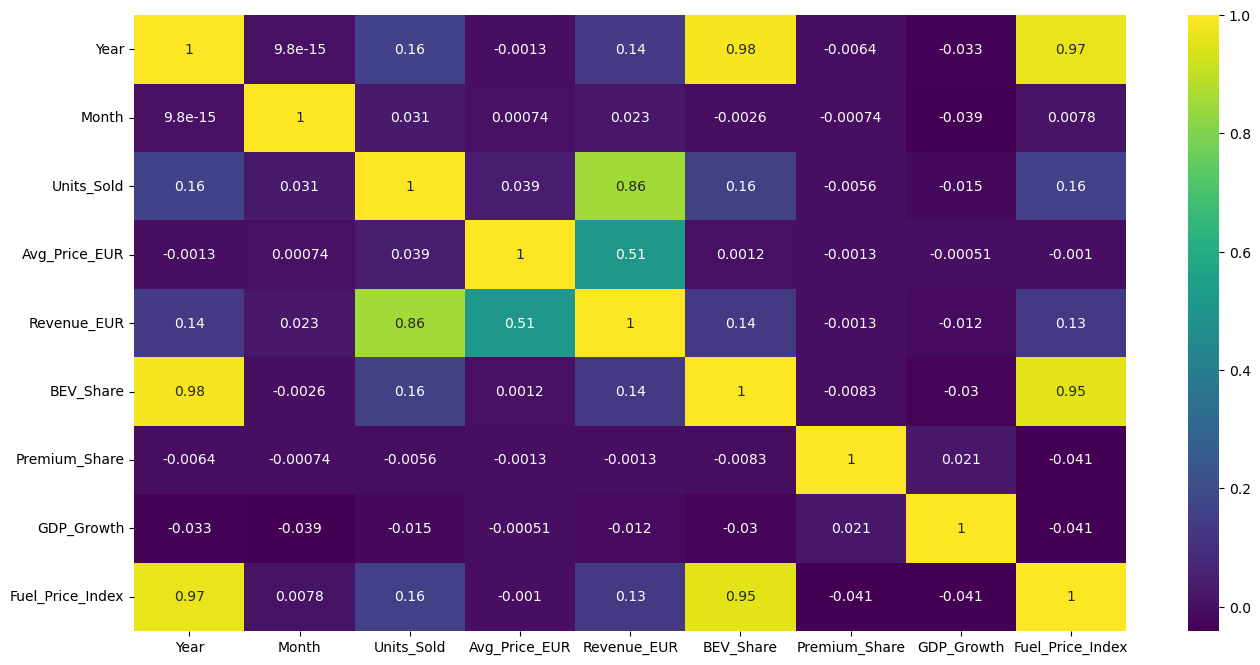

In [11]:
plt.figure(figsize=(16,8))
sns.heatmap(car.corr(), annot=True,cmap='viridis')

## Univariate Analysis On Numerical Columns

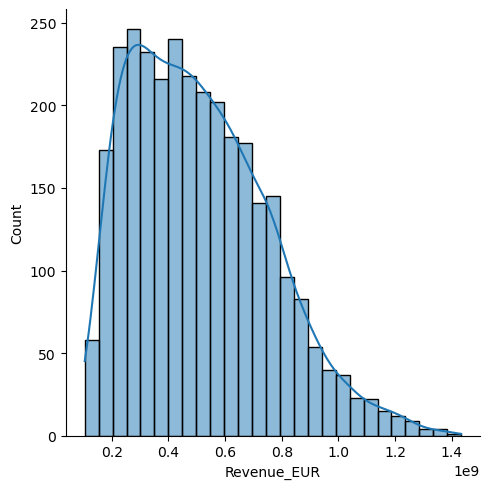

In [12]:
sns.displot(car['Revenue_EUR'],kde=True)

## Log-Normal Distribution

In [13]:
log_price = np.log1p(car['Revenue_EUR'])

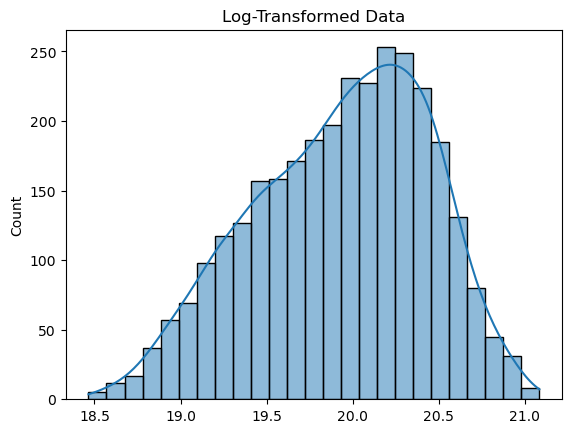

In [14]:
sns.histplot(data = sorted(log_price), kde=True)
plt.title("Log-Transformed Data")
plt.show()

## Box Plot To Check For Outliers On Every Numerical Columns

<AxesSubplot: >

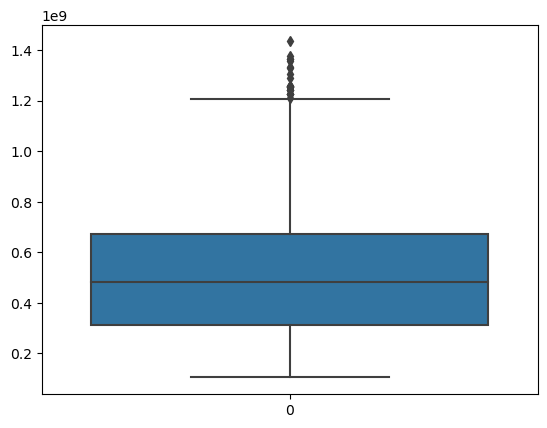

In [15]:
a = sorted(car['Revenue_EUR'])
sns.boxplot(a)

In [16]:
# Calculate IQR Of Revenue Column Of BMW
Q1 = car['Revenue_EUR'].quantile(0.25)
Q3 = car['Revenue_EUR'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

#Calculate Upper Bound & Lower Bound
Upper_Bound = Q1 - (1.5*IQR)
Lower_Bound = Q3 + (1.5*IQR)

print(f"IQR: {IQR}")
print(f"Maximum Value Of Revenue Column: {Upper_Bound}")
print(f"Minimum Value Of Revenue Column: {Lower_Bound}")

IQR: 358363776.25
Maximum Value Of Revenue Column: -224995312.125
Minimum Value Of Revenue Column: 1208459792.875


In [17]:
df1 = car[car['Revenue_EUR'] > 1208459792.875]

In [18]:
df1

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
452,2019,3,Europe,X7,13295,91058,1210616110,0.046,16.50,4.40,1.00
836,2020,3,Europe,X7,13645,91053,1242418185,0.059,15.31,4.48,1.09
1124,2020,12,Europe,X7,13404,93509,1253394636,0.074,14.13,2.66,1.11
1316,2021,6,Europe,X7,13799,90011,1242061789,0.104,17.30,1.33,1.15
1428,2021,9,USA,X7,14215,93386,1327481990,0.092,18.52,3.18,1.11
1516,2021,12,China,X7,14353,91024,1306467472,0.095,16.14,3.31,1.12
1524,2021,12,USA,X7,13944,90129,1256758776,0.078,14.85,2.49,1.15
1700,2022,6,Europe,X7,14100,91334,1287809400,0.112,20.37,3.07,1.12
1820,2022,9,RestOfWorld,X7,13417,91272,1224596424,0.118,6.95,3.43,1.18
1892,2022,12,Europe,X7,13906,90555,1259257830,0.117,14.24,1.31,1.22


In [19]:
df1['Region'].value_counts()

Europe         11
China           6
USA             3
RestOfWorld     3
Name: Region, dtype: int64

### Conclusion
* The raw data was slightly skewed, but the log transformation reveals a clear underlying Normal Distribution, proving the data is Log-Normal.

* The data appears to be accurate. Surprisingly, the BMW X7 has secured the top-selling model in Europe compared to other regions.

* A majority of consumers are transitioning toward the BMW X7, this shift toward SUVs suggests that buyers are prioritizing comfort and utility over raw speed and traditional styling.

## 2. What is the total sales volume (units sold) by region?

<AxesSubplot: xlabel='Region', ylabel='Units_Sold'>

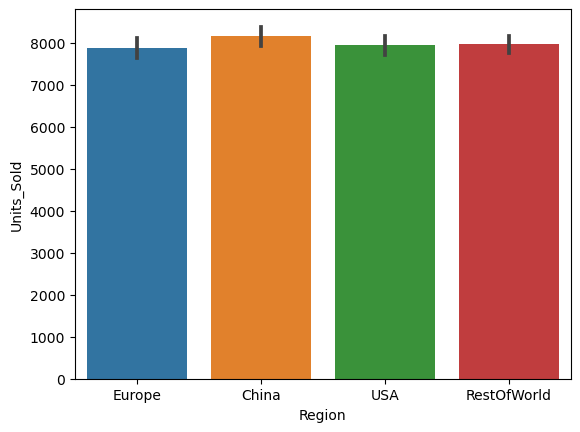

In [20]:
sns.barplot(data=car,x = car['Region'],y=car['Units_Sold'])

## Univariate Analysis Of Categorical Columns

<AxesSubplot: ylabel='Model'>

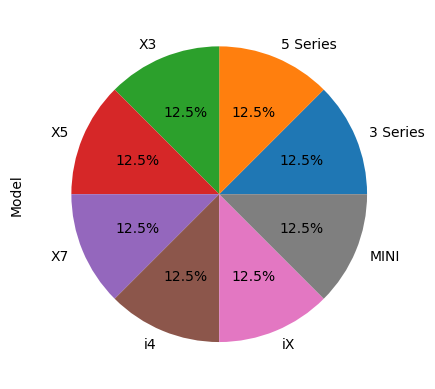

In [21]:
car['Model'].value_counts().plot(kind='pie',autopct = '%0.1f%%' )

<AxesSubplot: ylabel='Region'>

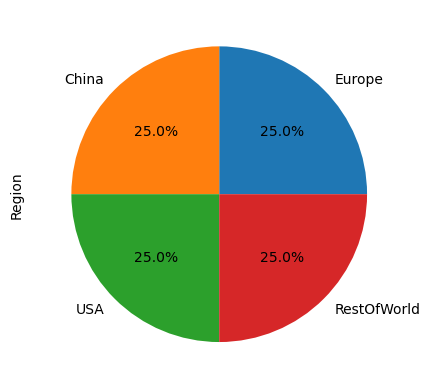

In [22]:
car['Region'].value_counts().plot(kind='pie',autopct = '%0.1f%%' )

In [23]:
pd.crosstab(car['Model'],car['Region'],normalize='columns')*100

Region,China,Europe,RestOfWorld,USA
Model,,,,
3 Series,12.5,12.5,12.5,12.5
5 Series,12.5,12.5,12.5,12.5
MINI,12.5,12.5,12.5,12.5
X3,12.5,12.5,12.5,12.5
X5,12.5,12.5,12.5,12.5
X7,12.5,12.5,12.5,12.5
i4,12.5,12.5,12.5,12.5
iX,12.5,12.5,12.5,12.5


### Conclusion
* BMW maintains a balanced sales distribution for all models across every region.
* BMW models maintains a balanced sales distribution across all regions.

## Bivariate & Multivariate Analysis

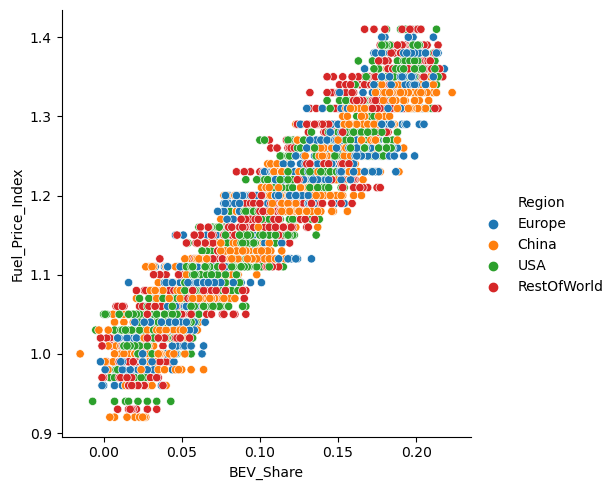

In [24]:
sns.relplot(data=car,x=car['BEV_Share'],y= car['Fuel_Price_Index'],hue='Region')
plt.show()

### Conclusion
* It indicates that there's postitive correlation between fuel price index and bev (Battery Electric Value) share. 

<AxesSubplot: xlabel='Year', ylabel='Revenue_EUR'>

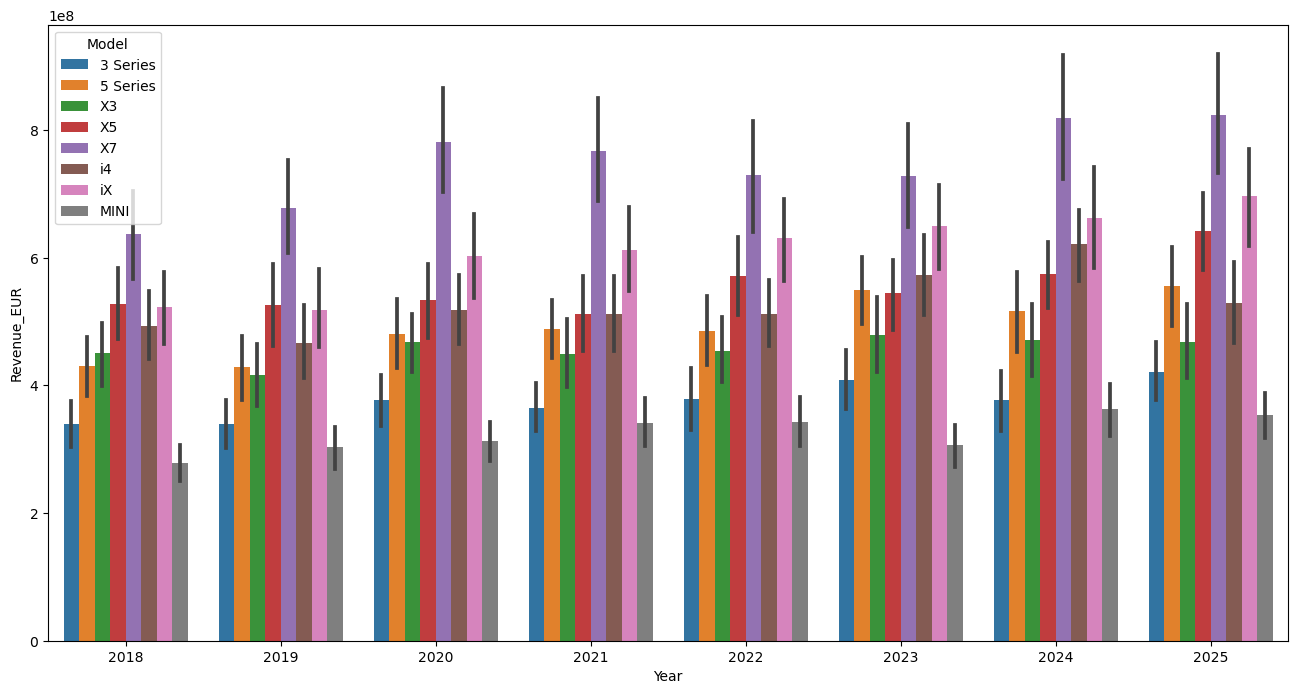

In [25]:
plt.figure(figsize=(16,8))
sns.barplot(data = car,x = car['Year'],y = car['Revenue_EUR'],hue= "Model")

<AxesSubplot: xlabel='Month', ylabel='Revenue_EUR'>

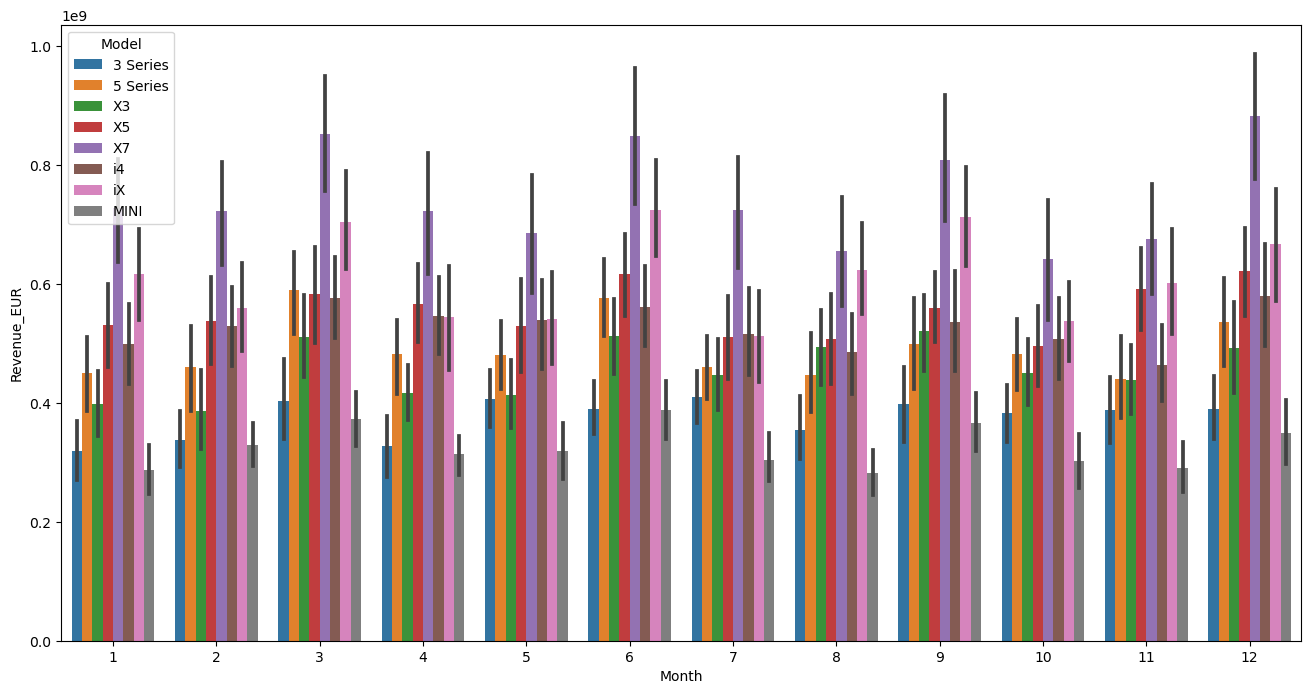

In [26]:
plt.figure(figsize=(16,8))
sns.barplot(data = car,x = car['Month'],y = car['Revenue_EUR'],hue= "Model" )

<AxesSubplot: xlabel='Year', ylabel='Units_Sold'>

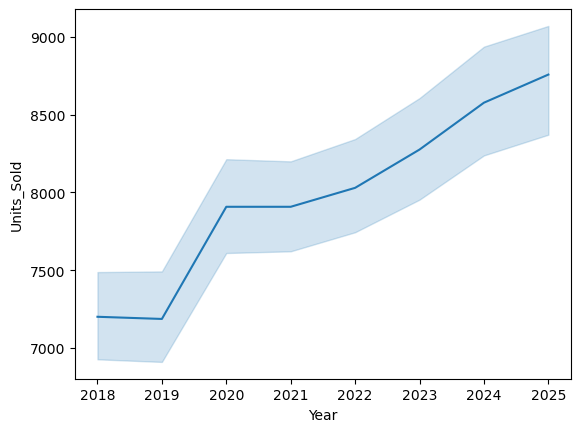

In [33]:
sns.lineplot(data = car, x = car['Year'],y = car['Units_Sold'])

<AxesSubplot: xlabel='Month', ylabel='Units_Sold'>

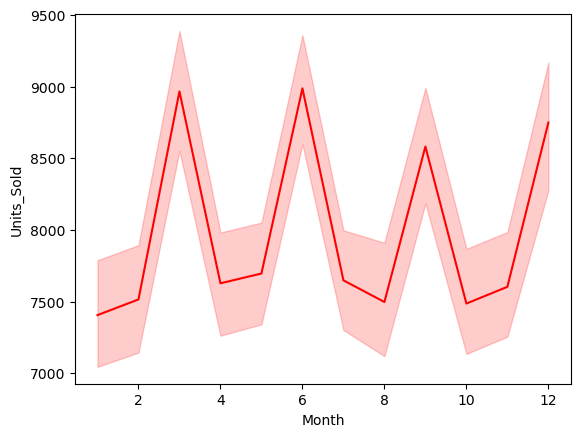

In [35]:
sns.lineplot(data = car, x = car['Month'], y = car['Units_Sold'],color= 'Red')